In [5]:
# Import necessary libraries
import kagglehub
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Embedding
from tensorflow.keras import layers, optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# some code insipred by https://keras.io/guides/training_with_built_in_methods/

# Download latest version of IMDB dataset
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print("Path to dataset files:", path)

# Load dataset
data = pd.read_csv(path + '/IMDB Dataset.csv')

# Separate features and target
X = data['review']
# Encode target variable ('sentiment') as binary (0 = 'negative', 1 = 'positive')
y = data['sentiment'].apply(lambda x: 0 if x == 'negative' else 1)


# Tokenize features ('review')
tokenizer = keras.preprocessing.text.Tokenizer(10000)
tokenizer.fit_on_texts(X)
total_words = 10000#len(tokenizer.word_index) + 1 # Size of the vocabulary
sequences = tokenizer.texts_to_sequences(X)
X = keras.preprocessing.sequence.pad_sequences(sequences, maxlen=200)


#splits data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



# Train model
model = Sequential()

# Input and hidden layers
model.add(Embedding(input_dim=total_words, output_dim=128))

# Convolution layer
hidden_layer1 = layers.Conv1D(128, 5, activation='relu')
model.add(hidden_layer1)

# model.add(layers.Dropout(0.3))

# Pooling layer
hiddenLayer2 = layers.GlobalMaxPooling1D()
model.add(hiddenLayer2)

# Fully Connected layer
hiddenLayer3 = layers.Dense(64, activation='relu')
model.add(hiddenLayer3)

# Binary Classification layer
output_layer = layers.Dense(1, activation='sigmoid')
model.add(output_layer)

#after creating model configure it
model.compile(loss = 'binary_crossentropy',optimizer= optimizers.Adam(learning_rate=0.001), metrics = ['accuracy'])

# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=1,
#     restore_best_weights=True
# )

history = model.fit(X_train, y_train, validation_split=0.20, epochs=3)
# history = model.fit(X_train, y_train, validation_split=0.20, epochs=10, callbacks=[early_stop])
model.summary()

results = model.evaluate(X_test, y_test)
print("test loss, test acc:", results)

# Pridict unseen data
# predictions = model.predict(x_test[:3])

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews
Epoch 1/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 111s 110ms/step - accuracy: 0.7529 - loss: 0.4690 - val_accuracy: 0.8953 - val_loss: 0.2492
Epoch 2/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 119s 119ms/step - accuracy: 0.9472 - loss: 0.1459 - val_accuracy: 0.8971 - val_loss: 0.2579
Epoch 3/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 125s 102ms/step - accuracy: 0.9916 - loss: 0.0351 - val_accuracy: 0.8982 - val_loss: 0.3331


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (32, 200, 128)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (32, 196, 128)         │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (32, 128)              │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (32, 64)               │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (32, 1)                │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,111,109 (15.68 MB)

 Trainable params: 1,370,369 (5.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,740,740 (10.46 MB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8962 - loss: 0.3274
test loss, test acc: [0.3348940908908844, 0.8949999809265137]


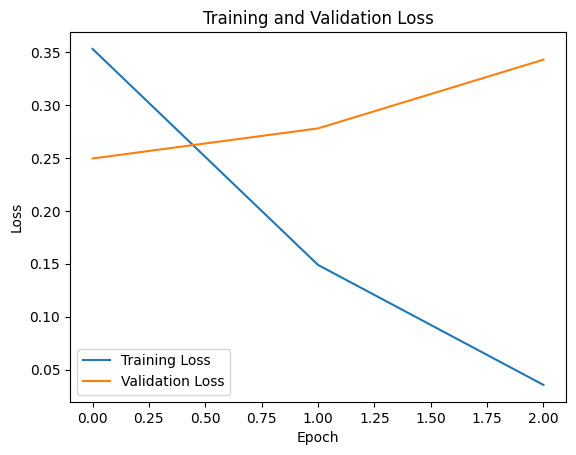

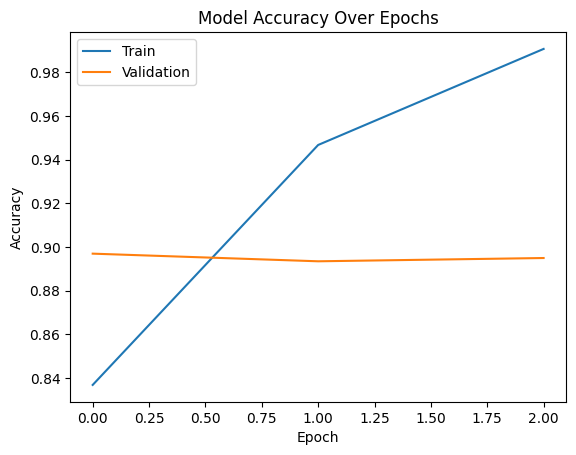

In [4]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.legend(['Train', 'Validation'])
plt.show()